<a href="https://colab.research.google.com/github/sukritipyakurel/NeuralNetwork/blob/main/Simple_Regression_Model_BEI_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Examples:** Ohm's Law, ADC calibration, LED characteristics

In [1]:
# ========================================
# CALCULATION EXAMPLE
# ========================================
print("\n\n" + "=" * 50)
print("MANUAL CALCULATION EXAMPLE")
print("=" * 50)
print("Let's calculate for a simple dataset:\n")



MANUAL CALCULATION EXAMPLE
Let's calculate for a simple dataset:



In [2]:
x = [1, 2, 3, 4, 5]
y = [2, 4, 5, 4, 5]

print(f"x data: {x}")
print(f"y data: {y}\n")

n = len(x)
print(f"Step 1: n = {n}")

x data: [1, 2, 3, 4, 5]
y data: [2, 4, 5, 4, 5]

Step 1: n = 5


In [3]:
sum_x = sum(x)
sum_y = sum(y)
sum_xy = sum(xi * yi for xi, yi in zip(x, y))
sum_x_squared = sum(xi * xi for xi in x)

print(f"Step 2: Σx = {sum_x}, Σy = {sum_y}")
print(f"Step 3: Σ(xy) = {sum_xy}")
print(f"Step 4: Σ(x²) = {sum_x_squared}")

slope = (n * sum_xy - sum_x * sum_y) / (n * sum_x_squared - sum_x * sum_x)

print(f"\nStep 5: Calculate slope")
print(f"  m = (n*Σ(xy) - Σx*Σy) / (n*Σ(x²) - (Σx)²)")
print(f"  m = ({n}*{sum_xy} - {sum_x}*{sum_y}) / ({n}*{sum_x_squared} - {sum_x}²)")
print(f"  m = {slope:.2f}")

intercept = (sum_y - slope * sum_x) / n

print(f"\nStep 6: Calculate intercept")
print(f"  b = (Σy - m*Σx) / n")
print(f"  b = ({sum_y} - {slope:.2f}*{sum_x}) / {n}")
print(f"  b = {intercept:.2f}")

print(f"\n✓ Final Equation: y = {slope:.2f}x + {intercept:.2f}")

Step 2: Σx = 15, Σy = 20
Step 3: Σ(xy) = 66
Step 4: Σ(x²) = 55

Step 5: Calculate slope
  m = (n*Σ(xy) - Σx*Σy) / (n*Σ(x²) - (Σx)²)
  m = (5*66 - 15*20) / (5*55 - 15²)
  m = 0.60

Step 6: Calculate intercept
  b = (Σy - m*Σx) / n
  b = (20 - 0.60*15) / 5
  b = 2.20

✓ Final Equation: y = 0.60x + 2.20


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

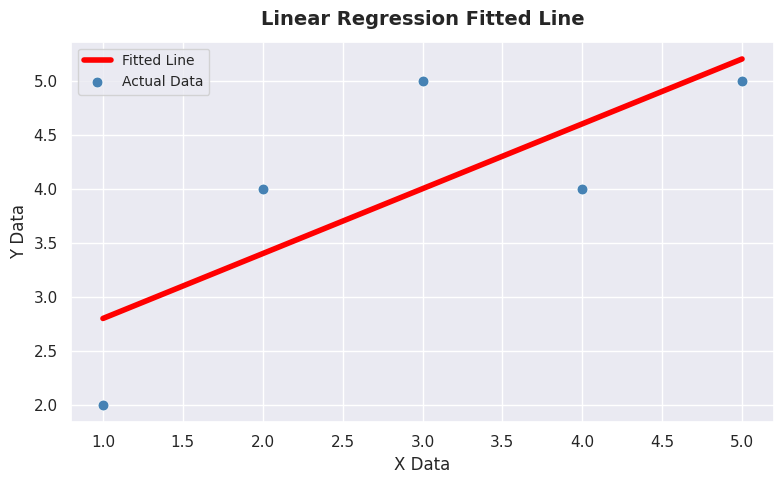

In [18]:
x_label = "X Data"
y_label = "Y Data"
title = "Linear Regression Fitted Line"

# Calculate predicted y values for the fitted line
predictions = [slope * val + intercept for val in x]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, predictions, color="red", linewidth=4,
            label="Fitted Line", zorder=4)

ax.scatter(x, y, color="steelblue", s=60, zorder=5,
               label="Actual Data", edgecolors="white", linewidths=0.5)


ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel(x_label, fontsize=12)
ax.set_ylabel(y_label, fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [5]:
import math
"""
    Simple Linear Regression: y = mx + b

    m = slope
    b = y-intercept

    Fit line using Least Squares Method

    Formulas:
    slope (m) = (n*Σ(xy) - Σx*Σy) / (n*Σ(x²) - (Σx)²)
    intercept (b) = (Σy - m*Σx) / n
    """
class SimpleLinearRegression:

    def __init__(self):
        self.slope = 0      # m
        self.intercept = 0  # b

    def train(self, x_data, y_data):
        n = len(x_data)  # number of data points

        # Sums needed
        sum_x = sum(x_data)
        sum_y = sum(y_data)
        sum_xy = sum(x * y for x, y in zip(x_data, y_data))
        sum_x_squared = sum(x * x for x in x_data)

        # slope (m)
        self.slope = (n * sum_xy - sum_x * sum_y)/ (n * sum_x_squared - sum_x * sum_x)

        # intercept (b)
        self.intercept = (sum_y - self.slope * sum_x) / n

        print(f"Training complete!")
        print(f"Equation: y = {self.slope:.4f}x + {self.intercept:.4f}")

    def predict(self, x):
        """
        Predict y value for a given x
        Simply use: y = mx + b
        """
        return self.slope * x + self.intercept

    def predict_multiple(self, x_list):
        """Predict y values for multiple x values"""
        return [self.predict(x) for x in x_list]

    def calculate_error(self, x_data, y_data):
        """
        Calculate Mean Squared Error (MSE)
        Shows how well our line fits the data
        """
        predictions = self.predict_multiple(x_data)
        errors = [(pred - actual) ** 2 for pred, actual in zip(predictions, y_data)]
        mse = sum(errors) / len(errors)

        # Also calculate R² (coefficient of determination)
        y_mean = sum(y_data) / len(y_data)
        ss_total = sum((y - y_mean) ** 2 for y in y_data)
        ss_residual = sum(errors)
        r_squared = 1 - (ss_residual / ss_total)

        print(f"\nMean Squared Error: {mse:.4f}")
        print(f"R² Score: {r_squared:.4f} (closer to 1 is better)")

        return mse, r_squared

In [6]:
# ========================================
# EXAMPLE 1: OHM'S LAW (V = IR)
# ========================================
print("=" * 50)
print("EXAMPLE 1: Ohm's Law - Voltage vs Current")
print("=" * 50)
print("For a resistor, V = I × R")
print("Let's find the resistance from measurements\n")

# Let the Measured data: Current (mA) vs Voltage (V)
current_mA = [10, 20, 30, 40, 50, 60, 70, 80]
voltage_V = [1.0, 2.1, 2.9, 4.0, 5.1, 6.0, 7.1, 8.0]
# Create and train model
model1 = SimpleLinearRegression()
model1.train(current_mA, voltage_V)

print(f"\nResistance ≈ {model1.slope:.2f} V/mA = {model1.slope * 1000:.2f} Ω")

# Make predictions
print("\nPredictions:")
test_currents = [25, 45, 65]
for current in test_currents:
    predicted_voltage = model1.predict(current)
    print(f"  Current = {current} mA → Voltage ≈ {predicted_voltage:.2f} V")

# Check accuracy
model1.calculate_error(current_mA, voltage_V)

EXAMPLE 1: Ohm's Law - Voltage vs Current
For a resistor, V = I × R
Let's find the resistance from measurements

Training complete!
Equation: y = 0.1005x + 0.0036

Resistance ≈ 0.10 V/mA = 100.48 Ω

Predictions:
  Current = 25 mA → Voltage ≈ 2.52 V
  Current = 45 mA → Voltage ≈ 4.53 V
  Current = 65 mA → Voltage ≈ 6.53 V

Mean Squared Error: 0.0043
R² Score: 0.9992 (closer to 1 is better)


(0.004255952380952379, 0.9991976524320109)

In [7]:
# ========================================
# EXAMPLE 2: TEMPERATURE SENSOR CALIBRATION
# ========================================
print("\n\n" + "=" * 50)
print("EXAMPLE 2: Temperature Sensor Calibration")
print("=" * 50)
print("ADC Reading vs Actual Temperature\n")

# ADC readings (0-1023) vs Actual temperature (°C)
adc_reading = [100, 200, 300, 400, 500, 600, 700, 800]
temperature = [10, 20, 30, 40, 50, 60, 70, 80]

model2 = SimpleLinearRegression()
model2.train(adc_reading, temperature)

print(f"\nCalibration equation found!")
print(f"Temperature (°C) = {model2.slope:.4f} × ADC + {model2.intercept:.2f}")

# Predict temperature for new ADC readings
print("\nPredictions:")
test_adc = [250, 550, 750]
for adc in test_adc:
    temp = model2.predict(adc)
    print(f"  ADC = {adc} → Temperature ≈ {temp:.2f}°C")

model2.calculate_error(adc_reading, temperature)



EXAMPLE 2: Temperature Sensor Calibration
ADC Reading vs Actual Temperature

Training complete!
Equation: y = 0.1000x + 0.0000

Calibration equation found!
Temperature (°C) = 0.1000 × ADC + 0.00

Predictions:
  ADC = 250 → Temperature ≈ 25.00°C
  ADC = 550 → Temperature ≈ 55.00°C
  ADC = 750 → Temperature ≈ 75.00°C

Mean Squared Error: 0.0000
R² Score: 1.0000 (closer to 1 is better)


(0.0, 1.0)

In [8]:
# ========================================
# EXAMPLE 3: LED BRIGHTNESS vs CURRENT
# ========================================
print("\n\n" + "=" * 50)
print("EXAMPLE 3: LED Brightness vs Current")
print("=" * 50)
print("Find relationship between LED current and brightness\n")

# Current (mA) vs Brightness (lux)
led_current = [5, 10, 15, 20, 25, 30, 35, 40]
brightness = [12, 25, 38, 50, 63, 75, 88, 100]

model3 = SimpleLinearRegression()
model3.train(led_current, brightness)

print(f"\nBrightness (lux) = {model3.slope:.2f} × Current(mA) + {model3.intercept:.2f}")

# What current for desired brightness?
desired_brightness = 60
required_current = (desired_brightness - model3.intercept) / model3.slope
print(f"\nFor {desired_brightness} lux brightness:")
print(f"  Required current ≈ {required_current:.2f} mA")

model3.calculate_error(led_current, brightness)



EXAMPLE 3: LED Brightness vs Current
Find relationship between LED current and brightness

Training complete!
Equation: y = 2.5119x + -0.1429

Brightness (lux) = 2.51 × Current(mA) + -0.14

For 60 lux brightness:
  Required current ≈ 23.94 mA

Mean Squared Error: 0.0908
R² Score: 0.9999 (closer to 1 is better)


(0.09077380952381013, 0.9998904008185802)

VISUALIZATION: Ohm's Law Data


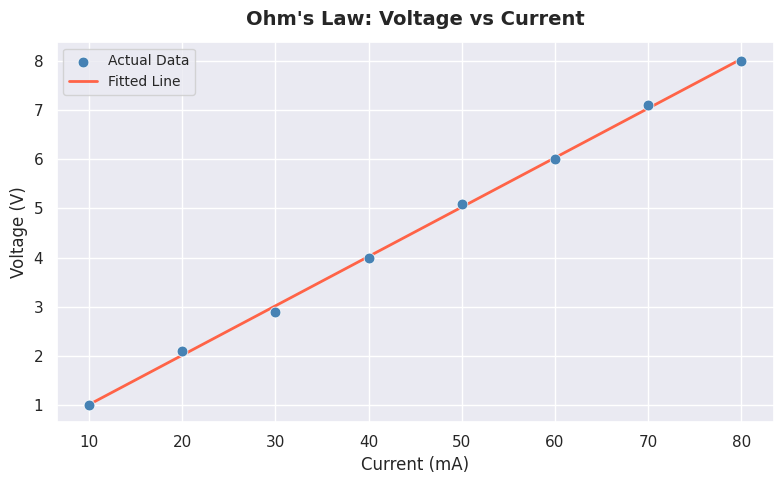

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ========================================
# PLOTTING FUNCTION
# ========================================
def plot_regression(x_data, y_data, predictions, title="Regression Fit",
                    x_label="X", y_label="Y"):
    """
    Create a scatter plot with regression line using matplotlib/seaborn.
    * actual data points are shown as scatter
    * regression line is plotted from predictions
    """
    sns.set_theme(style="darkgrid")
    fig, ax = plt.subplots(figsize=(8, 5))

    # Plot actual data points
    ax.scatter(x_data, y_data, color="steelblue", s=60, zorder=5,
               label="Actual Data", edgecolors="white", linewidths=0.5)

    # Sort by x for a clean line
    sorted_pairs = sorted(zip(x_data, predictions))
    x_sorted, y_pred_sorted = zip(*sorted_pairs)

    # Plot regression line
    ax.plot(x_sorted, y_pred_sorted, color="tomato", linewidth=2,
            label="Fitted Line", zorder=4)

    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()


# ========================================
# VISUALIZATION: Ohm's Law Data
# ========================================
print("=" * 50)
print("VISUALIZATION: Ohm's Law Data")
print("=" * 50)

predictions = model1.predict_multiple(current_mA)

plot_regression(
    x_data=current_mA,
    y_data=voltage_V,
    predictions=predictions,
    title="Ohm's Law: Voltage vs Current",
    x_label="Current (mA)",
    y_label="Voltage (V)"
)